# Demo 3 - Demonstração - Comparação de Métricas

### MBA em AI Engineering & Multi Agents - Machine Learning Foundations & Classic Models.

### Prof. Dr. Ahirton Lopes (profahirton.lopes@fiap.com.br)

Ref. https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html


Nossos imports serão o pandas, o datasets, nosso modelo linear e train_test_split do sckitlearn bem como o matplotlib:

In [1]:
import pandas as pd
from sklearn import datasets, linear_model
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

Vamos analisar rapidamente as bibliotecas que importamos:

Pandas - para carregar o arquivo de dados como um dataframe do Pandas e analisar os dados;

No Sklearn, importamos o módulo de conjuntos de dados (databases) para carregar uma base de amostra e o linear_model para executar uma regressão linear;

No Sklearn, com a sub-biblioteca model_selection, importamos então train_test_split para que possamos dividir corretamente nossos dados em conjuntos de treinamento e teste;

Do Matplotlib, importamos o pyplot para plotar gráficos dos dados.

In [2]:
# Carregando o dataset 'diabetes'

# Declarando os nomes de nossas colunas
columns = 'age sex bmi map tc ldl hdl tch ltg glu'.split()

# Carregando o dataset 'diabetes'do sklearn
diabetes = datasets.load_diabetes()

# Carregando o dataset como um pandas dataframe
df = pd.DataFrame(diabetes.data, columns=columns)

#Definindo nossa variável 'alvo' (dependente) como y
y = diabetes.target

In [3]:
# Criando nossos sets de treinamento e teste (Lembre-se, comumente será em uma proporçao de 70/30 ou 80/20)
# random_state fixo: sem ele, cada execução sorteia uma divisão diferente e o score muda bastante
# (nesta base, o R² vai de ~0.33 a ~0.46 só trocando a semente)
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42)
print (X_train.shape, y_train.shape)
print (X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


Agora, ajustaremos o modelo aos dados de treinamento (model fitting):

In [4]:
# Model fitting
lm = linear_model.LinearRegression()
model = lm.fit(X_train, y_train)
predictions = lm.predict(X_test)

Como você pode ver, estamos ajustando o modelo nos dados de treinamento e tentando prever os dados de teste.

Vamos ver algumas das previsões:


In [5]:
predictions[0:5]

array([139.5475584 , 179.51720835, 134.03875572, 291.41702925,
       123.78965872])

Obs: como usamos [0: 5] após as previsões, mostra-se então apenas os cinco primeiros valores previstos.

Remover o [0: 5] faria com que fossem imprimidos todos os valores previstos que nosso modelo criou.

Agora vamos plotar nosso modelo de regressão linear:

Text(0, 0.5, 'Predicoes')

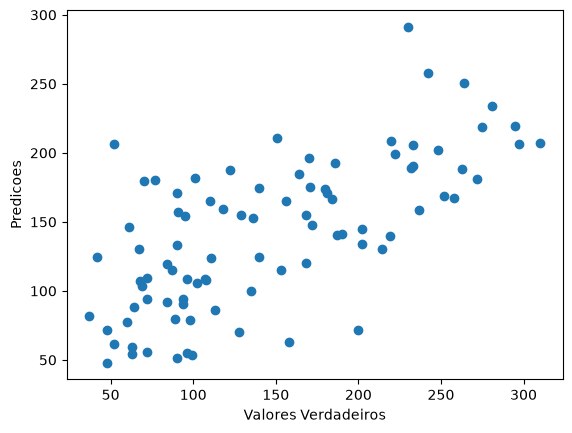

In [6]:
## Modelo de regressao linear
plt.scatter(y_test, predictions)
plt.xlabel('Valores Verdadeiros')
plt.ylabel('Predicoes')

Score R² para nosso modelo.

Atenção: o `.score()` da regressão linear no scikit-learn devolve o **R²**, não acurácia. Acurácia é métrica de classificação, e aqui estamos em um problema de regressão:

In [7]:
print ('R² (holdout):', model.score(X_test, y_test))

R² (holdout): 0.45260276297191926


## Comparando métricas de regressão

O R² responde "quanto da variação dos dados o modelo explica", mas não diz **de quanto** ele erra na prática. Para isso existem outras métricas, e cada uma responde a uma pergunta diferente:

*   **MAE (Mean Absolute Error, Erro Absoluto Médio)**: a média do tamanho dos erros, ignorando o sinal. Fica na **mesma unidade do alvo**, então é a mais fácil de explicar para quem não é técnico ("em média o modelo erra X unidades"). Trata todos os erros com o mesmo peso.

*   **MSE (Mean Squared Error, Erro Quadrático Médio)**: eleva cada erro ao quadrado antes de tirar a média, então **um erro grande pesa muito mais** do que vários pequenos. Em compensação a unidade fica ao quadrado, o que atrapalha a leitura.

*   **RMSE (Root Mean Squared Error)**: a raiz quadrada do MSE, que traz o valor de volta para a unidade original. Mantém a punição aos erros grandes e continua legível. Regra prática: **se o RMSE for bem maior que o MAE, existem alguns erros grandes puxando o resultado**, em vez de um erro espalhado por igual.

*   **MAPE (Mean Absolute Percentage Error)**: o erro como porcentagem do valor real. Serve para comparar problemas de escalas diferentes, mas **quebra quando o alvo tem valores próximos de zero** (a divisão explode) e pune a subestimação mais do que a superestimação.

*   **R² (coeficiente de determinação)**: a proporção da variância explicada. Vale 1 para um modelo perfeito, **0 para um modelo equivalente a chutar sempre a média** e fica negativo quando o modelo é pior do que essa média.

*   **R² ajustado**: o R² tem um defeito, ele nunca piora quando você acrescenta uma variável nova, mesmo que ela seja inútil. O R² ajustado desconta o número de variáveis usadas, então **cai quando a variável adicionada não ajuda**. É o indicado para comparar modelos com quantidades diferentes de features.

Não existe "a métrica certa": a escolha depende do que custa caro no problema. Se errar muito em poucos casos é o desastre (risco de crédito, previsão de demanda), olhe o RMSE. Se todo erro custa proporcionalmente igual, o MAE já resolve.

In [8]:
import numpy as np
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             mean_absolute_percentage_error, r2_score)

# Recalculamos as predições do holdout aqui para a célula ser independente
# da ordem em que você executar o notebook
predictions = lm.predict(X_test)

# Toda métrica compara o que o modelo previu (predictions)
# com o valor real que ele deveria ter acertado (y_test) - nessa ordem
mae  = mean_absolute_error(y_test, predictions)
mse  = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)   # a raiz devolve o erro para a unidade original do alvo
mape = mean_absolute_percentage_error(y_test, predictions)
r2   = r2_score(y_test, predictions)

# R² ajustado: 1 - (1 - R²) * (n - 1) / (n - p - 1)
n = X_test.shape[0]   # amostras de teste
p = X_test.shape[1]   # variáveis independentes
r2_ajustado = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f'MAE   (erro absoluto médio)     : {mae:9.2f}')
print(f'MSE   (erro quadrático médio)   : {mse:9.2f}')
print(f'RMSE  (raiz do erro quadrático) : {rmse:9.2f}')
print(f'MAPE  (erro percentual médio)   : {mape:9.2%}')
print(f'R²    (variância explicada)     : {r2:9.4f}')
print(f'R² ajustado (com {p} variáveis)   : {r2_ajustado:9.4f}')
print()
print(f'Referência: o alvo no teste vai de {y_test.min():.0f} a {y_test.max():.0f}, com média {y_test.mean():.1f}')

MAE   (erro absoluto médio)     :     42.79
MSE   (erro quadrático médio)   :   2900.19
RMSE  (raiz do erro quadrático) :     53.85
MAPE  (erro percentual médio)   :    37.50%
R²    (variância explicada)     :    0.4526
R² ajustado (com 10 variáveis)   :    0.3824

Referência: o alvo no teste vai de 37 a 310, com média 145.8


### Esse resultado é bom?

Número solto não significa nada. Ele só vira informação quando comparado com uma **referência (baseline)**: o melhor resultado que alguém conseguiria sem modelo nenhum.

Em regressão esse baseline é prever **sempre a média** do conjunto de treinamento, ignorando todas as variáveis de entrada. É contra ele que o modelo precisa provar que aprendeu alguma coisa. Note que o R² do baseline fica em torno de zero, que é exatamente o que a definição da métrica diz.

In [9]:
from sklearn.dummy import DummyRegressor

# O baseline mais honesto para regressão: prever sempre a média do treino
baseline = DummyRegressor(strategy='mean').fit(X_train, y_train)
pred_baseline = baseline.predict(X_test)

print(f'{"métrica":<10s} {"modelo":>12s} {"baseline":>12s}')
print('-' * 36)
print(f'{"MAE":<10s} {mean_absolute_error(y_test, predictions):12.2f} {mean_absolute_error(y_test, pred_baseline):12.2f}')
print(f'{"RMSE":<10s} {np.sqrt(mean_squared_error(y_test, predictions)):12.2f} {np.sqrt(mean_squared_error(y_test, pred_baseline)):12.2f}')
print(f'{"MAPE":<10s} {mean_absolute_percentage_error(y_test, predictions):12.2%} {mean_absolute_percentage_error(y_test, pred_baseline):12.2%}')
print(f'{"R²":<10s} {r2_score(y_test, predictions):12.4f} {r2_score(y_test, pred_baseline):12.4f}')

métrica          modelo     baseline
------------------------------------
MAE               42.79        64.01
RMSE              53.85        73.22
MAPE             37.50%       62.79%
R²               0.4526      -0.0120


### Lendo os números deste exemplo

*   O modelo erra em média **42.8 unidades** (MAE) num alvo que, no conjunto de teste, vai de 37 a 310. É um erro grande, e o MAPE confirma: **37.5%** de desvio percentual médio.

*   O **RMSE (53.9) é bem maior que o MAE (42.8)**. Pela regra prática que vimos acima, isso indica que o erro não está distribuído por igual: existem casos em que o modelo erra muito mais do que a média. Se errar feio em poucos casos for o problema mais caro, é o RMSE que você deve acompanhar.

*   O **R² ajustado (0.38) é menor que o R² (0.45)** porque estamos usando 10 variáveis. Essa diferença é o preço de manter variáveis que contribuem pouco. Vale o exercício de treinar de novo com menos features e observar qual dos dois números cai.

*   Contra o baseline, o modelo **ganha em todas as métricas** (MAE 42.8 contra 64.0, R² 0.45 contra praticamente zero). Ou seja, ele realmente aprendeu algo a partir das variáveis, mesmo estando longe de ser preciso.

A leitura honesta é que este modelo explica menos da metade da variação do alvo. Para uma aplicação real na área de saúde isso dificilmente seria aceitável, e é justamente esse tipo de julgamento que as métricas existem para permitir.

## Exercício de fixação e Desafio - Validação Cruzada, K-Pastas e Leave One Out


**[Desafio]** Como desafio, atentem para a utilização do mesmo exemplo mas dessa vez com a utilização de validação via validação cruzada via K-Pastas (K-Folds Cross Validation)  e, a posteriori, façam o mesmo exemplo dessa vez com validação via Método Leave One Out (como visto em aula).

Referências:

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.LeaveOneOut.html

In [10]:
# Imports necessários

from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn import metrics

In [11]:
# Fazendo nossa validação cruzada em 8 k-pastas

scores = cross_val_score(model, df, y, cv=8)
print ('Scores com Validação Cruzada:', scores)

Scores com Validação Cruzada: [0.50283895 0.18991137 0.56539742 0.36996399 0.6004718  0.33262207
 0.41403457 0.68713432]


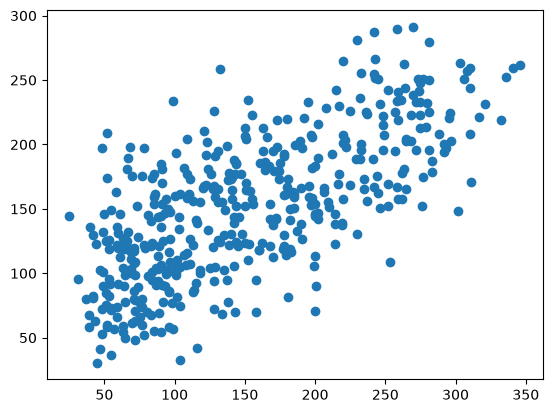

In [12]:
# Fazendo predições com nossa validação cruzada (mesmo cv=8 da célula anterior)

predictions = cross_val_predict(model, df, y, cv=8)
plt.scatter(y, predictions)

Repare que este gráfico é bem diferente do anterior.

No primeiro, plotamos apenas os 89 pontos do conjunto de teste do holdout. Aqui aparecem os 442 pontos do dataset inteiro, porque o `cross_val_predict` devolve exatamente uma predição para cada amostra: a predição feita na rodada em que aquela amostra ficou de fora do treino. Ou seja, a quantidade de pontos vem do tamanho do dataset, e não do valor de `cv`.

Por fim, vamos verificar a pontuação R² do modelo.

R² é a proporção da variação na variável dependente que é explicada pelas variáveis independentes.

Atenção, de novo: R² não é acurácia. Acurácia é uma métrica de classificação (proporção de acertos), e em regressão não existe "acertou ou errou", existe erro maior ou menor. O R² mede quanto da variância dos dados o modelo consegue explicar:

In [13]:
r2 = metrics.r2_score(y, predictions)
print ('R² via Predição Cruzada:', r2)

R² via Predição Cruzada: 0.49210473269881627


Para mais informações sobre outros scores/métricas favor consultar:

Ref. https://stanford.edu/~shervine/teaching/cs-229/cheatsheet-machine-learning-tips-and-tricks